In [10]:
import torch
print(torch.__version__)
import sklearn
print(sklearn.__version__)

2.6.0+cu124
1.8.0


In [11]:
# Imports

import torch
import torch.nn as nn
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

sys.path.append('..')

In [12]:
import os
os.chdir(os.path.dirname(os.path.abspath('evaluate.ipynb')))
print(f'Working directory: {os.getcwd()}')

Working directory: f:\vs code\.vscode\Final-Project(2)\DeepfakeDetectorProject\notebooks


In [13]:
# Load Preprocessing & Model

import sys
sys.path.append('..')

from models.efficientnet_model import DeepfakeDetector

%run preprocessing.ipynb
print("---------------------------")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = DeepfakeDetector(num_classes=2)
model.load_state_dict(torch.load('../saved_models/best_model.pth', map_location=device))
model = model.to(device)
model.eval()
print('Model loaded successfully')

Train : 100000 images
Val   : 20000 images
Test  : 20000  images
Classes: {'fake': 0, 'real': 1}
---------------------------
Using device: cuda
Model loaded successfully


In [14]:
# Run on Test Set

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds)  * 100
precision = precision_score(all_labels, all_preds) * 100
recall    = recall_score(all_labels, all_preds)    * 100
f1        = f1_score(all_labels, all_preds)        * 100

print(f'Accuracy  : {acc:.2f}%')
print(f'Precision : {precision:.2f}%')
print(f'Recall    : {recall:.2f}%')
print(f'F1 Score  : {f1:.2f}%')

Accuracy  : 91.61%
Precision : 94.15%
Recall    : 88.73%
F1 Score  : 91.36%


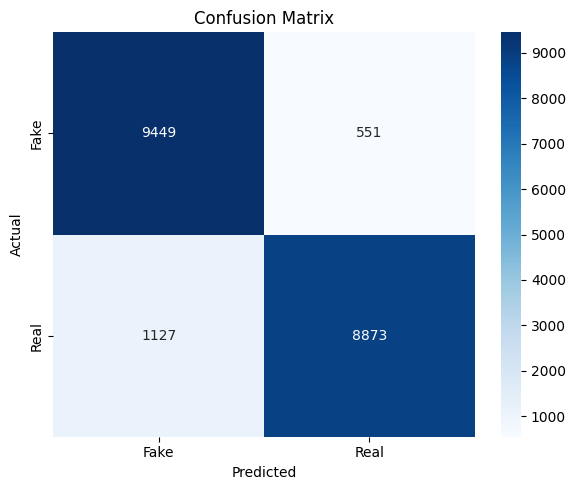

Saved.


In [15]:
# Confusion Matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../saved_models/confusion_matrix.png')
plt.show()
print('Saved.')

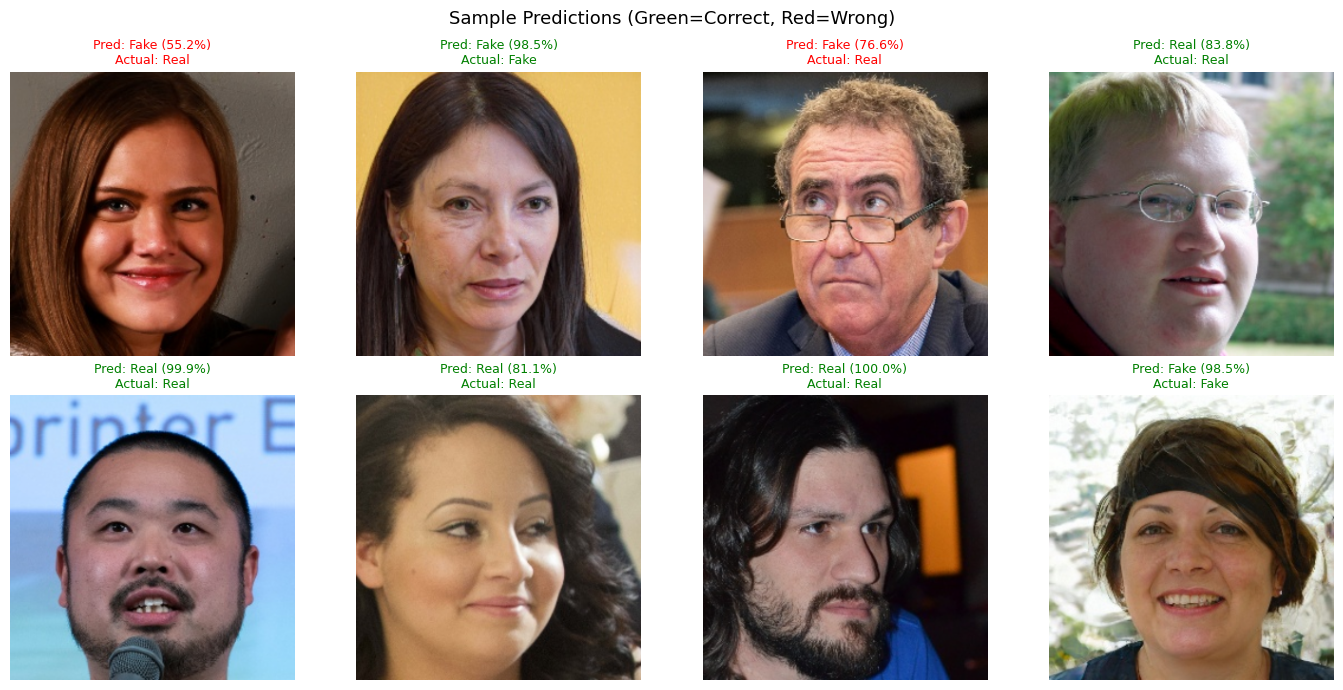

Saved.


In [16]:
# Sample Predictions

# Show 8 sample images with predicted vs actual label
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
class_names = ['Fake', 'Real']

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds   = outputs.argmax(dim=1)
    probs   = torch.softmax(outputs, dim=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img * STD + MEAN).clip(0, 1)

    pred_label   = class_names[preds[i].item()]
    actual_label = class_names[labels[i].item()]
    confidence   = probs[i][preds[i]].item() * 100

    color = 'green' if pred_label == actual_label else 'red'
    ax.imshow(img)
    ax.set_title(f'Pred: {pred_label} ({confidence:.1f}%)\nActual: {actual_label}',
                 color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('../saved_models/sample_predictions.png')
plt.show()
print('Saved.')